In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("swasthya_vardhan_genetic_prototype_10000.csv")

df.head()

,patient_id,sex,age,ancestry_group,HEIGHT_SNP_01,HEIGHT_SNP_02,HEIGHT_SNP_03,HEIGHT_SNP_04,HEIGHT_SNP_05,HEIGHT_SNP_06,...,strength_score,power_score,endurance_score,auditory_score,neuromotor_score,primary_domain,secondary_domain,primary_domain_score,domain_confidence,dataset_split
0,SV100000,Male,58,Hispanic_Latin_American,1,0,0,0,1,0,...,43.1,39.0,40.2,49.0,45.9,Music_Auditory,Endurance_Sports,59.4,80.4,validation
1,SV100001,Female,45,South_Asian,1,0,0,0,1,0,...,25.9,68.6,52.5,40.9,26.0,Endurance_Sports,Sports_Athletics,48.1,58.2,train
2,SV100002,Male,58,South_Asian,1,0,0,0,1,1,...,59.8,36.9,70.3,54.9,40.5,Endurance_Sports,Sports_Athletics,60.4,60.7,train
3,SV100003,Female,34,African,0,0,0,0,1,0,...,77.8,58.0,77.5,35.0,59.0,Sports_Athletics,Endurance_Sports,67.7,55.7,test
4,SV100004,Female,37,South_Asian,2,0,0,0,0,1,...,45.9,59.9,61.4,52.3,62.1,Endurance_Sports,Fast_Response_Sports,63.6,60.8,train


In [2]:
df.shape

(10000, 60)

In [3]:
df.columns.tolist()

['patient_id',
 'sex',
 'age',
 'ancestry_group',
 'HEIGHT_SNP_01',
 'HEIGHT_SNP_02',
 'HEIGHT_SNP_03',
 'HEIGHT_SNP_04',
 'HEIGHT_SNP_05',
 'HEIGHT_SNP_06',
 'STRENGTH_SNP_01',
 'STRENGTH_SNP_02',
 'STRENGTH_SNP_03',
 'STRENGTH_SNP_04',
 'STRENGTH_SNP_05',
 'STRENGTH_SNP_06',
 'POWER_SNP_01',
 'POWER_SNP_02',
 'POWER_SNP_03',
 'POWER_SNP_04',
 'ENDURANCE_SNP_01',
 'ENDURANCE_SNP_02',
 'ENDURANCE_SNP_03',
 'ENDURANCE_SNP_04',
 'ENDURANCE_SNP_05',
 'ENDURANCE_SNP_06',
 'AUDITORY_SNP_01',
 'AUDITORY_SNP_02',
 'AUDITORY_SNP_03',
 'AUDITORY_SNP_04',
 'NEUROMOTOR_SNP_01',
 'NEUROMOTOR_SNP_02',
 'NEUROMOTOR_SNP_03',
 'NEUROMOTOR_SNP_04',
 'height_pgs',
 'strength_pgs',
 'power_pgs',
 'endurance_pgs',
 'auditory_pgs',
 'neuromotor_pgs',
 'measured_height_cm',
 'grip_strength_kg',
 'estimated_vo2max',
 'reaction_time_ms',
 'pitch_discrimination_score',
 'sports_training_hours_week',
 'music_training_hours_week',
 'family_sports_history',
 'family_music_history',
 'height_score',
 'strength_sco

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 60 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  10000 non-null  object 
 1   sex                         10000 non-null  object 
 2   age                         10000 non-null  int64  
 3   ancestry_group              10000 non-null  object 
 4   HEIGHT_SNP_01               10000 non-null  int64  
 5   HEIGHT_SNP_02               10000 non-null  int64  
 6   HEIGHT_SNP_03               10000 non-null  int64  
 7   HEIGHT_SNP_04               10000 non-null  int64  
 8   HEIGHT_SNP_05               10000 non-null  int64  
 9   HEIGHT_SNP_06               10000 non-null  int64  
 10  STRENGTH_SNP_01             10000 non-null  int64  
 11  STRENGTH_SNP_02             10000 non-null  int64  
 12  STRENGTH_SNP_03             10000 non-null  int64  
 13  STRENGTH_SNP_04             1000

In [5]:
df.isnull().sum().sum()

0

In [6]:
df["primary_domain"].value_counts()

primary_domain
Music_Auditory          3555
Fast_Response_Sports    2496
Endurance_Sports        2458
Sports_Athletics        1491
Name: count, dtype: int64

In [7]:
snp_columns = [col for col in df.columns if "SNP" in col]
print("Number of SNP features:" , len(snp_columns))
print("\nSNP features:")
print(snp_columns)

Number of SNP features: 30

SNP features:
['HEIGHT_SNP_01', 'HEIGHT_SNP_02', 'HEIGHT_SNP_03', 'HEIGHT_SNP_04', 'HEIGHT_SNP_05', 'HEIGHT_SNP_06', 'STRENGTH_SNP_01', 'STRENGTH_SNP_02', 'STRENGTH_SNP_03', 'STRENGTH_SNP_04', 'STRENGTH_SNP_05', 'STRENGTH_SNP_06', 'POWER_SNP_01', 'POWER_SNP_02', 'POWER_SNP_03', 'POWER_SNP_04', 'ENDURANCE_SNP_01', 'ENDURANCE_SNP_02', 'ENDURANCE_SNP_03', 'ENDURANCE_SNP_04', 'ENDURANCE_SNP_05', 'ENDURANCE_SNP_06', 'AUDITORY_SNP_01', 'AUDITORY_SNP_02', 'AUDITORY_SNP_03', 'AUDITORY_SNP_04', 'NEUROMOTOR_SNP_01', 'NEUROMOTOR_SNP_02', 'NEUROMOTOR_SNP_03', 'NEUROMOTOR_SNP_04']


In [8]:
X = df[snp_columns]
print("X shape:" , X.shape)
print("\nFirst 5 rows:")
X.head()

X shape: (10000, 30)

First 5 rows:


,HEIGHT_SNP_01,HEIGHT_SNP_02,HEIGHT_SNP_03,HEIGHT_SNP_04,HEIGHT_SNP_05,HEIGHT_SNP_06,STRENGTH_SNP_01,STRENGTH_SNP_02,STRENGTH_SNP_03,STRENGTH_SNP_04,...,ENDURANCE_SNP_05,ENDURANCE_SNP_06,AUDITORY_SNP_01,AUDITORY_SNP_02,AUDITORY_SNP_03,AUDITORY_SNP_04,NEUROMOTOR_SNP_01,NEUROMOTOR_SNP_02,NEUROMOTOR_SNP_03,NEUROMOTOR_SNP_04
0,1,0,0,0,1,0,1,0,0,0,...,0,0,0,1,1,1,0,2,0,0
1,1,0,0,0,1,0,1,0,0,0,...,0,1,0,0,1,1,1,2,0,1
2,1,0,0,0,1,1,1,0,0,1,...,0,1,0,1,1,0,0,1,0,1
3,0,0,0,0,1,0,0,2,1,1,...,1,2,1,1,1,2,1,0,1,0
4,2,0,0,0,0,1,1,1,1,1,...,0,1,0,1,1,0,0,0,0,1


In [9]:
y = df["height_score"]
print("Target shape:" , y.shape)
print("\nFirst 10 target values:")
print(y.head(10))

Target shape: (10000,)

First 10 target values:
0    49.3
1    49.3
2    64.2
3    40.1
4    68.7
5    69.0
6    49.3
7    44.8
8    65.2
9    63.5
Name: height_score, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


In [11]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [12]:
y_pred = model.predict(X_test)

print("First 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred[:10])

First 10 actual values:
[40.1 35.5 66.  18.1 38.3 58.5 49.3 59.5 68.7 54. ]

First 10 predicted values:
[40.1 35.5 66.  18.1 38.3 58.5 49.3 59.5 68.7 54. ]


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Model Performance
------------------
MAE : 0.166
RMSE: 0.817
R²  : 0.997


Top 15 most important genetic features:
HEIGHT_SNP_06        0.380622
HEIGHT_SNP_02        0.240567
HEIGHT_SNP_01        0.175816
HEIGHT_SNP_03        0.134852
HEIGHT_SNP_05        0.046393
HEIGHT_SNP_04        0.019747
STRENGTH_SNP_04      0.000133
ENDURANCE_SNP_01     0.000118
ENDURANCE_SNP_04     0.000113
POWER_SNP_02         0.000107
POWER_SNP_03         0.000105
AUDITORY_SNP_03      0.000101
NEUROMOTOR_SNP_01    0.000094
POWER_SNP_04         0.000093
NEUROMOTOR_SNP_02    0.000090
dtype: float64


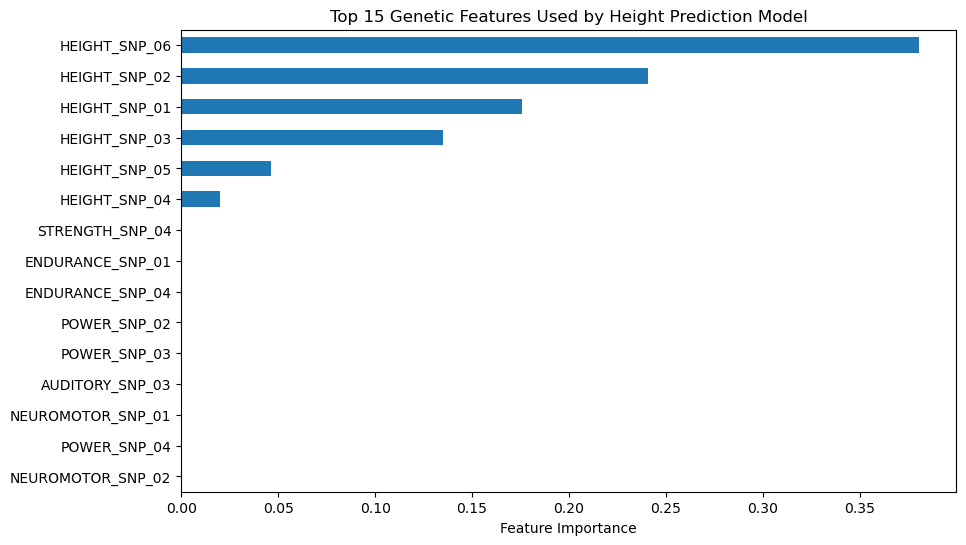

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 most important genetic features:")
print(importance.head(15))

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Genetic Features Used by Height Prediction Model")
plt.xlabel("Feature Importance")
plt.show()

In [15]:
# Check correlations between genetic features and the height target

height_features = [col for col in df.columns if "HEIGHT_SNP" in col]

print("Height genetic features:")
print(height_features)

print("\nCorrelation with height_score:")
print(
    df[height_features + ["height_score"]]
    .corr()["height_score"]
    .sort_values(ascending=False)
)

Height genetic features:
['HEIGHT_SNP_01', 'HEIGHT_SNP_02', 'HEIGHT_SNP_03', 'HEIGHT_SNP_04', 'HEIGHT_SNP_05', 'HEIGHT_SNP_06']

Correlation with height_score:
height_score     1.000000
HEIGHT_SNP_06    0.622384
HEIGHT_SNP_01    0.427090
HEIGHT_SNP_03    0.366796
HEIGHT_SNP_05    0.220488
HEIGHT_SNP_04    0.155067
HEIGHT_SNP_02   -0.484747
Name: height_score, dtype: float64


In [16]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Create a fresh model
cv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# 5-fold cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=cv,
    scoring="r2"
)

print("5-Fold Cross-Validation R² Scores:")
print(scores)

print("\nMean CV R²:", round(scores.mean(), 3))
print("Std CV R²:", round(scores.std(), 3))

5-Fold Cross-Validation R² Scores:
[0.99700513 0.9969366  0.99590773 0.99773593 0.99651899]

Mean CV R²: 0.997
Std CV R²: 0.001


In [17]:
# Genetic trait columns
trait_targets = [
    "height_score",
    "strength_score",
    "power_score",
    "endurance_score",
    "auditory_score",
    "neuromotor_score"
]

print("Trait targets:")
print(trait_targets)

print("\nTrait statistics:")
print(df[trait_targets].describe().T[["mean", "std", "min", "max"]])

Trait targets:
['height_score', 'strength_score', 'power_score', 'endurance_score', 'auditory_score', 'neuromotor_score']

Trait statistics:
                      mean        std   min    max
height_score      49.99488  14.989194  13.5  100.0
strength_score    49.99886  13.271141   4.2   94.1
power_score       49.99884  11.349400  16.9   88.7
endurance_score   49.99874  13.576680   9.9   93.6
auditory_score    49.99942  13.680778  13.7   94.4
neuromotor_score  50.00246  12.887893   1.2   83.8


In [18]:
print("X columns containing target names:")
for target in trait_targets:
    matches = [c for c in X.columns if target.lower() in c.lower()]
    print(target, matches)

print("\nTrain/Test overlap:")
print(set(X_train.index).intersection(set(X_test.index)))

X columns containing target names:
height_score []
strength_score []
power_score []
endurance_score []
auditory_score []
neuromotor_score []

Train/Test overlap:
set()


In [19]:
# Check whether height_score is mathematically generated
# from the SNP features

print("Height score correlation with all SNPs:")
print(
    df[snp_columns + ["height_score"]]
    .corr()["height_score"]
    .sort_values(ascending=False)
)

print("\nTarget unique values:", df["height_score"].nunique())
print("Total samples:", len(df))

Height score correlation with all SNPs:
height_score         1.000000
HEIGHT_SNP_06        0.622384
HEIGHT_SNP_01        0.427090
HEIGHT_SNP_03        0.366796
HEIGHT_SNP_05        0.220488
HEIGHT_SNP_04        0.155067
ENDURANCE_SNP_01     0.015743
ENDURANCE_SNP_02     0.015465
ENDURANCE_SNP_03     0.011588
NEUROMOTOR_SNP_04    0.011500
ENDURANCE_SNP_05     0.009767
ENDURANCE_SNP_06     0.007548
STRENGTH_SNP_05      0.005935
AUDITORY_SNP_02      0.005823
STRENGTH_SNP_04      0.005102
NEUROMOTOR_SNP_01    0.005084
POWER_SNP_02         0.004407
STRENGTH_SNP_01      0.003538
STRENGTH_SNP_02      0.003338
AUDITORY_SNP_03      0.001686
STRENGTH_SNP_06     -0.000486
POWER_SNP_03        -0.001633
NEUROMOTOR_SNP_03   -0.004049
POWER_SNP_04        -0.005018
POWER_SNP_01        -0.005832
ENDURANCE_SNP_04    -0.006401
AUDITORY_SNP_04     -0.011744
AUDITORY_SNP_01     -0.011921
NEUROMOTOR_SNP_02   -0.012032
STRENGTH_SNP_03     -0.025037
HEIGHT_SNP_02       -0.484747
Name: height_score, dtype: flo

In [20]:
# Check model performance against a simple baseline

from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline R²:", round(r2_score(y_test, baseline_pred), 3))
print("Baseline MAE:", round(mean_absolute_error(y_test, baseline_pred), 3))
print("Baseline RMSE:", round(np.sqrt(mean_squared_error(y_test, baseline_pred)), 3))

Baseline R²: -0.001
Baseline MAE: 11.945
Baseline RMSE: 14.887


In [21]:
# Check whether height_score is deterministically related
# to the height SNPs

height_snps = [
    c for c in df.columns
    if "HEIGHT_SNP" in c
]

print("Height SNP distributions:")
for col in height_snps:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())

print("\nHeight score distribution:")
print(df["height_score"].value_counts().sort_index().head(30))

Height SNP distributions:

HEIGHT_SNP_01
HEIGHT_SNP_01
0    3994
1    4660
2    1346
Name: count, dtype: int64

HEIGHT_SNP_02
HEIGHT_SNP_02
0    4196
1    4570
2    1234
Name: count, dtype: int64

HEIGHT_SNP_03
HEIGHT_SNP_03
0    7800
1    2062
2     138
Name: count, dtype: int64

HEIGHT_SNP_04
HEIGHT_SNP_04
0    7575
1    2258
2     167
Name: count, dtype: int64

HEIGHT_SNP_05
HEIGHT_SNP_05
0    3079
1    5009
2    1912
Name: count, dtype: int64

HEIGHT_SNP_06
HEIGHT_SNP_06
0    5654
1    3716
2     630
Name: count, dtype: int64

Height score distribution:
height_score
13.5     43
18.1     86
22.7    100
22.8     31
24.5    204
25.6     14
27.3    104
27.4     10
28.3     37
29.1    368
30.1      1
30.2     22
31.8     16
31.9     27
32.0     39
32.9     16
33.0     48
33.7    314
33.8    100
34.7     13
34.8      7
34.9      5
35.5    166
36.4      7
36.5     92
36.6     10
37.5     42
37.6     36
38.3    430
38.4     21
Name: count, dtype: int64


In [22]:
# Compare actual height_score with a simple linear combination
# of the height SNPs

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

height_model = LinearRegression()

height_model.fit(df[height_snps], df["height_score"])

height_pred = height_model.predict(df[height_snps])

print("Linear regression using ONLY height SNPs")
print("R²:", round(r2_score(df["height_score"], height_pred), 4))

print("\nCoefficients:")
for name, coef in zip(height_snps, height_model.coef_):
    print(name, round(coef, 4))

Linear regression using ONLY height SNPs
R²: 0.9999

Coefficients:
HEIGHT_SNP_01 9.1731
HEIGHT_SNP_02 -10.99
HEIGHT_SNP_03 12.0396
HEIGHT_SNP_04 4.5908
HEIGHT_SNP_05 4.6484
HEIGHT_SNP_06 14.8409


In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
train_pred = height_model.predict(X_train[height_snps])
test_pred = height_model.predict(X_test[height_snps])

print("Train R²:", round(r2_score(y_train, train_pred), 4))
print("Test R²:", round(r2_score(y_test, test_pred), 4))

print("Test MAE:", round(mean_absolute_error(y_test, test_pred), 3))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred)), 3))

Train R²: 0.9999
Test R²: 0.9999
Test MAE: 0.03
Test RMSE: 0.112


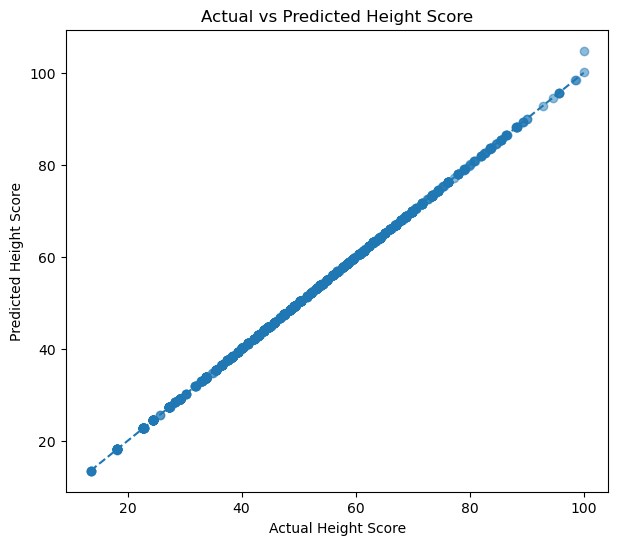

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.5)

plt.xlabel("Actual Height Score")
plt.ylabel("Predicted Height Score")
plt.title("Actual vs Predicted Height Score")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [25]:
# Check prediction errors
residuals = y_test - test_pred

print("Residual statistics:")
print("Mean residual:", round(residuals.mean(), 4))
print("Std residual:", round(residuals.std(), 4))
print("Max absolute error:", round(np.abs(residuals).max(), 4))

# Show largest errors
error_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": test_pred,
    "error": residuals.values,
    "abs_error": np.abs(residuals.values)
})

print("\nLargest prediction errors:")
print(error_df.sort_values("abs_error", ascending=False).head(10))

Residual statistics:
Mean residual: 0.0006
Std residual: 0.1122
Max absolute error: 4.7968

Largest prediction errors:
      actual   predicted     error  abs_error
58     100.0  104.796762 -4.796762   4.796762
1512   100.0  100.205996 -0.205996   0.205996
977     98.6   98.490249  0.109751   0.109751
253     74.5   74.410147  0.089853   0.089853
692     90.1   90.013557  0.086443   0.086443
788     90.1   90.013557  0.086443   0.086443
1228    86.5   86.414730  0.085270   0.085270
244     78.0   77.915397  0.084603   0.084603
1995    89.3   89.215994  0.084006   0.084006
218     89.3   89.215994  0.084006   0.084006


In [26]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    LinearRegression(),
    df[height_snps],
    df["height_score"],
    cv=cv,
    scoring="r2"
)

print("5-Fold CV R² scores:", np.round(cv_scores, 4))
print("Mean CV R²:", round(cv_scores.mean(), 4))
print("Std CV R²:", round(cv_scores.std(), 4))

5-Fold CV R² scores: [0.9999 1.     0.9997 0.9999 0.9999]
Mean CV R²: 0.9999
Std CV R²: 0.0001


In [27]:
print("Checking possible leakage...")

for snp in height_snps:
    print(
        snp,
        "unique values =", df[snp].nunique(),
        "target unique =", df["height_score"].nunique()
    )

print("\nCorrelation with target:")
print(df[height_snps + ["height_score"]].corr()["height_score"].sort_values())

Checking possible leakage...
HEIGHT_SNP_01 unique values = 3 target unique = 216
HEIGHT_SNP_02 unique values = 3 target unique = 216
HEIGHT_SNP_03 unique values = 3 target unique = 216
HEIGHT_SNP_04 unique values = 3 target unique = 216
HEIGHT_SNP_05 unique values = 3 target unique = 216
HEIGHT_SNP_06 unique values = 3 target unique = 216

Correlation with target:
HEIGHT_SNP_02   -0.484747
HEIGHT_SNP_04    0.155067
HEIGHT_SNP_05    0.220488
HEIGHT_SNP_03    0.366796
HEIGHT_SNP_01    0.427090
HEIGHT_SNP_06    0.622384
height_score     1.000000
Name: height_score, dtype: float64


In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [29]:
trait_snp_map = {
    "height_score": [c for c in df.columns if c.startswith("HEIGHT_SNP_")],
    "strength_score": [c for c in df.columns if c.startswith("STRENGTH_SNP_")],
    "power_score": [c for c in df.columns if c.startswith("POWER_SNP_")],
    "endurance_score": [c for c in df.columns if c.startswith("ENDURANCE_SNP_")],
    "auditory_score": [c for c in df.columns if c.startswith("AUDITORY_SNP_")],
    "neuromotor_score": [c for c in df.columns if c.startswith("NEUROMOTOR_SNP_")]
}

results = []

for trait, snps in trait_snp_map.items():
    X = df[snps]
    y = df[trait]

    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)

    results.append({
        "Trait": trait,
        "SNPs": len(snps),
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred))
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

              Trait  SNPs      R2     MAE    RMSE
0      height_score     6  0.9999  0.0302  0.1605
1    strength_score     6  0.9119  3.3271  3.9384
2       power_score     4  0.7871  4.1860  5.2371
3   endurance_score     6  0.9050  3.3309  4.1839
4    auditory_score     4  0.9114  3.2461  4.0730
5  neuromotor_score     4  0.8646  3.8071  4.7423


In [30]:
# Check whether height_score can be reconstructed from the height SNPs

import pandas as pd
import numpy as np

# Correlation matrix
corr = df[height_snps + ["height_score"]].corr()

print("Correlation with height_score:")
print(corr["height_score"].sort_values(ascending=False))

# Check whether the target is exactly determined by the SNPs
print("\nNumber of unique SNP combinations:",
      df[height_snps].drop_duplicates().shape[0])

print("Number of unique height scores:",
      df["height_score"].nunique())

Correlation with height_score:
height_score     1.000000
HEIGHT_SNP_06    0.622384
HEIGHT_SNP_01    0.427090
HEIGHT_SNP_03    0.366796
HEIGHT_SNP_05    0.220488
HEIGHT_SNP_04    0.155067
HEIGHT_SNP_02   -0.484747
Name: height_score, dtype: float64

Number of unique SNP combinations: 436
Number of unique height scores: 216


In [31]:
# Fit model again and examine residuals

height_model = LinearRegression()
height_model.fit(df[height_snps], df["height_score"])

pred = height_model.predict(df[height_snps])
residuals = df["height_score"] - pred

print("Maximum absolute residual:",
      np.max(np.abs(residuals)))

print("Mean absolute residual:",
      np.mean(np.abs(residuals)))

Maximum absolute residual: 12.245618940405478
Mean absolute residual: 0.03021869761909799


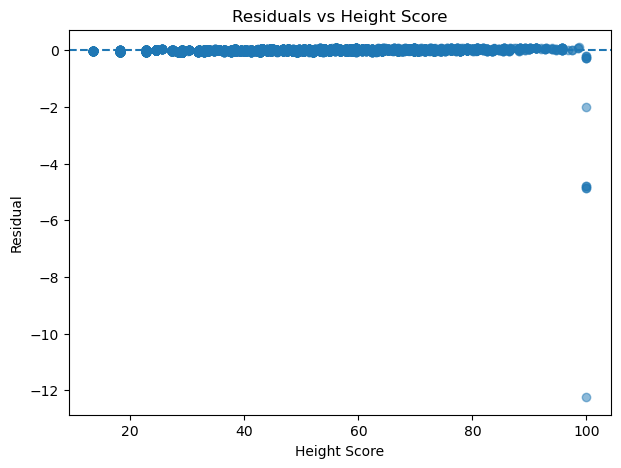

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(df["height_score"], residuals, alpha=0.5)

plt.axhline(0, linestyle="--")

plt.xlabel("Height Score")
plt.ylabel("Residual")
plt.title("Residuals vs Height Score")

plt.show()

In [33]:
# Identify observations with large residuals

error_df = pd.DataFrame({
    "actual": df["height_score"],
    "predicted": pred,
    "residual": residuals,
    "abs_error": np.abs(residuals)
})

print("Observations with |residual| > 1:")
print(
    error_df[error_df["abs_error"] > 1]
    .sort_values("abs_error", ascending=False)
)

Observations with |residual| > 1:
      actual   predicted   residual  abs_error
2642   100.0  112.245619 -12.245619  12.245619
1308   100.0  104.854444  -4.854444   4.854444
1353   100.0  104.854444  -4.854444   4.854444
2545   100.0  104.796762  -4.796762   4.796762
5845   100.0  104.796762  -4.796762   4.796762
9490   100.0  101.995499  -1.995499   1.995499


In [34]:
# Examine the SNP genotypes for the large-error observations

large_errors = error_df["abs_error"] > 1

print(
    df.loc[large_errors, height_snps + ["height_score"]]
)

      HEIGHT_SNP_01  HEIGHT_SNP_02  HEIGHT_SNP_03  HEIGHT_SNP_04  \
1308              2              0              1              0   
1353              2              0              1              0   
2545              2              0              1              1   
2642              2              0              2              0   
5845              2              0              1              1   
9490              2              0              2              1   

      HEIGHT_SNP_05  HEIGHT_SNP_06  height_score  
1308              2              2         100.0  
1353              2              2         100.0  
2545              1              2         100.0  
2642              1              2         100.0  
5845              1              2         100.0  
9490              1              1         100.0  


In [35]:
# Check duplicate SNP combinations and their height scores

combo_check = (
    df.groupby(height_snps)["height_score"]
      .agg(["count", "nunique", "min", "max"])
      .reset_index()
)

print(combo_check.sort_values("nunique", ascending=False).head(20))

     HEIGHT_SNP_01  HEIGHT_SNP_02  HEIGHT_SNP_03  HEIGHT_SNP_04  \
0                0              0              0              0   
287              1              2              0              2   
298              1              2              1              1   
297              1              2              1              1   
296              1              2              1              0   
295              1              2              1              0   
294              1              2              1              0   
293              1              2              1              0   
292              1              2              1              0   
291              1              2              1              0   
290              1              2              1              0   
289              1              2              1              0   
288              1              2              1              0   
286              1              2              0              

In [36]:
print("R²:", height_model.score(df[height_snps], df["height_score"]))

print("\nCoefficients:")
for snp, coef in zip(height_snps, height_model.coef_):
    print(snp, coef)

print("\nIntercept:", height_model.intercept_)

R²: 0.9998853508718929

Coefficients:
HEIGHT_SNP_01 9.173068496981635
HEIGHT_SNP_02 -10.990002108419894
HEIGHT_SNP_03 12.039623269195276
HEIGHT_SNP_04 4.590766688815335
HEIGHT_SNP_05 4.648448067092032
HEIGHT_SNP_06 14.840887007305502

Intercept: 35.490013326348624


In [37]:
print("R²:", height_model.score(df[height_snps], df["height_score"]))

print("\nCoefficients:")
for snp, coef in zip(height_snps, height_model.coef_):
    print(snp, coef)

print("\nIntercept:", height_model.intercept_)

R²: 0.9998853508718929

Coefficients:
HEIGHT_SNP_01 9.173068496981635
HEIGHT_SNP_02 -10.990002108419894
HEIGHT_SNP_03 12.039623269195276
HEIGHT_SNP_04 4.590766688815335
HEIGHT_SNP_05 4.648448067092032
HEIGHT_SNP_06 14.840887007305502

Intercept: 35.490013326348624


In [38]:
print(df.groupby(height_snps)["height_score"].agg(["count", "nunique", "min", "max"]).sort_values("nunique", ascending=False).head(20))

                                                                                     count  \
HEIGHT_SNP_01 HEIGHT_SNP_02 HEIGHT_SNP_03 HEIGHT_SNP_04 HEIGHT_SNP_05 HEIGHT_SNP_06          
0             0             0             0             0             0                166   
1             2             0             2             2             1                  2   
                            1             1             0             1                  5   
                                                                      0                  4   
                                          0             2             2                  1   
                                                                      1                  8   
                                                                      0                  8   
                                                        1             2                  3   
                                                            

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = df[height_snps]
y = df["height_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Test R²:", r2_score(y_test, pred))
print("Test MAE:", mean_absolute_error(y_test, pred))

Test R²: 0.9999430276285594
Test MAE: 0.030574324228614586


In [40]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = df[height_snps]
y = df["height_score"]

# Treat identical SNP combinations as one group
groups = df[height_snps].astype(str).agg("_".join, axis=1)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Grouped Test R²:", r2_score(y_test, pred))
print("Grouped Test MAE:", mean_absolute_error(y_test, pred))

Grouped Test R²: 0.9999932122483722
Grouped Test MAE: 0.028203531023771773


In [41]:
print("Total observations:", len(df))
print("Unique SNP combinations:", df[height_snps].drop_duplicates().shape[0])
print("Duplicate observations:",
      len(df) - df[height_snps].drop_duplicates().shape[0])

Total observations: 10000
Unique SNP combinations: 436
Duplicate observations: 9564


In [42]:
combo_counts = df.groupby(height_snps).size()

print(combo_counts.describe())
print("\nNumber of unique combinations:", len(combo_counts))
print("Maximum observations for one combination:", combo_counts.max())

count    436.000000
mean      22.935780
std       46.083587
min        1.000000
25%        2.000000
50%        6.000000
75%       21.000000
max      354.000000
dtype: float64

Number of unique combinations: 436
Maximum observations for one combination: 354


In [43]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

X = df[height_snps]
y = df["height_score"]

groups = df[height_snps].astype(str).agg("_".join, axis=1)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Grouped Test R²:", r2_score(y_test, pred))
print("Grouped Test MAE:", mean_absolute_error(y_test, pred))

print("Train unique combinations:",
      groups.iloc[train_idx].nunique())
print("Test unique combinations:",
      groups.iloc[test_idx].nunique())

print("Overlap:",
      len(set(groups.iloc[train_idx]) &
          set(groups.iloc[test_idx])))

Grouped Test R²: 0.9999932122483722
Grouped Test MAE: 0.028203531023771773
Train unique combinations: 348
Test unique combinations: 88
Overlap: 0


In [44]:
print(df[["height_score"] + height_snps].corr()["height_score"])

height_score     1.000000
HEIGHT_SNP_01    0.427090
HEIGHT_SNP_02   -0.484747
HEIGHT_SNP_03    0.366796
HEIGHT_SNP_04    0.155067
HEIGHT_SNP_05    0.220488
HEIGHT_SNP_06    0.622384
Name: height_score, dtype: float64


In [45]:
print(df[["height_score"] + height_snps].head(20))

    height_score  HEIGHT_SNP_01  HEIGHT_SNP_02  HEIGHT_SNP_03  HEIGHT_SNP_04  \
0           49.3              1              0              0              0   
1           49.3              1              0              0              0   
2           64.2              1              0              0              0   
3           40.1              0              0              0              0   
4           68.7              2              0              0              0   
5           69.0              1              2              1              1   
6           49.3              1              0              0              0   
7           44.8              0              0              0              0   
8           65.2              1              1              1              1   
9           63.5              0              1              0              0   
10          73.3              2              0              0              0   
11          49.3              1         

In [46]:
# Check whether each SNP combination has exactly one height_score
group_check = (
    df.groupby(height_snps)["height_score"]
      .agg(["count", "nunique", "min", "max", "std"])
)

print("Unique SNP combinations:", len(group_check))
print("Combinations with >1 height_score:",
      (group_check["nunique"] > 1).sum())

print("\nHeight-score variation within SNP combinations:")
print(group_check["std"].describe())

# Fit using ONE row per unique SNP combination
unique_df = df.drop_duplicates(subset=height_snps).copy()

X_unique = unique_df[height_snps]
y_unique = unique_df["height_score"]

unique_model = LinearRegression()
unique_model.fit(X_unique, y_unique)

unique_pred = unique_model.predict(X_unique)

print("\nUnique-combination model:")
print("R²:", r2_score(y_unique, unique_pred))
print("MAE:", mean_absolute_error(y_unique, unique_pred))
print("Maximum absolute error:",
      np.max(np.abs(y_unique - unique_pred)))

print("\nCoefficients:")
for snp, coef in zip(height_snps, unique_model.coef_):
    print(snp, "=", coef)

print("Intercept =", unique_model.intercept_)

Unique SNP combinations: 436
Combinations with >1 height_score: 0

Height-score variation within SNP combinations:
count    350.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: std, dtype: float64

Unique-combination model:
R²: 0.9985779261241914
MAE: 0.18188956522961286
Maximum absolute error: 11.788216773949102

Coefficients:
HEIGHT_SNP_01 = 9.077492494418596
HEIGHT_SNP_02 = -10.920890066016105
HEIGHT_SNP_03 = 11.945109139210745
HEIGHT_SNP_04 = 4.599664950483619
HEIGHT_SNP_05 = 4.628590698666642
HEIGHT_SNP_06 = 14.737517820144678
Intercept = 35.63938716773441


In [47]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import joblib

# --------------------------------------------------
# 1. ONE ROW PER UNIQUE SNP COMBINATION
# --------------------------------------------------
unique_df = df.drop_duplicates(subset=height_snps).copy()

X = unique_df[height_snps]
y = unique_df["height_score"]

print("Unique genotype combinations:", len(unique_df))

# --------------------------------------------------
# 2. 5-FOLD CROSS-VALIDATION
# --------------------------------------------------
model = LinearRegression()

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_pred = cross_val_predict(
    model,
    X,
    y,
    cv=cv
)

cv_r2 = r2_score(y, cv_pred)
cv_mae = mean_absolute_error(y, cv_pred)
cv_max_error = np.max(np.abs(y - cv_pred))

print("\n5-FOLD CROSS-VALIDATION")
print("R²:", cv_r2)
print("MAE:", cv_mae)
print("Maximum absolute error:", cv_max_error)

# --------------------------------------------------
# 3. FIT FINAL MODEL ON ALL 436 COMBINATIONS
# --------------------------------------------------
final_model = LinearRegression()
final_model.fit(X, y)

print("\nFINAL MODEL")
print("Intercept:", final_model.intercept_)

print("\nCoefficients:")
for snp, coef in zip(height_snps, final_model.coef_):
    print(f"{snp}: {coef:.6f}")

# --------------------------------------------------
# 4. FIND THE LARGEST PREDICTION ERRORS
# --------------------------------------------------
unique_df["predicted_height"] = final_model.predict(X)
unique_df["error"] = (
    unique_df["height_score"] - unique_df["predicted_height"]
)
unique_df["abs_error"] = unique_df["error"].abs()

print("\nLARGEST ERRORS:")
print(
    unique_df[
        height_snps +
        ["height_score", "predicted_height", "error", "abs_error"]
    ]
    .sort_values("abs_error", ascending=False)
    .head(10)
    .to_string(index=False)
)

# --------------------------------------------------
# 5. SAVE THE MODEL
# --------------------------------------------------
joblib.dump(
    {
        "model": final_model,
        "features": height_snps
    },
    "height_snp_model.pkl"
)

print("\nModel saved as: height_snp_model.pkl")

Unique genotype combinations: 436

5-FOLD CROSS-VALIDATION
R²: 0.9984743725353423
MAE: 0.18616337575961756
Maximum absolute error: 12.162913961365376

FINAL MODEL
Intercept: 35.63938716773441

Coefficients:
HEIGHT_SNP_01: 9.077492
HEIGHT_SNP_02: -10.920890
HEIGHT_SNP_03: 11.945109
HEIGHT_SNP_04: 4.599665
HEIGHT_SNP_05: 4.628591
HEIGHT_SNP_06: 14.737518

LARGEST ERRORS:
 HEIGHT_SNP_01  HEIGHT_SNP_02  HEIGHT_SNP_03  HEIGHT_SNP_04  HEIGHT_SNP_05  HEIGHT_SNP_06  height_score  predicted_height      error  abs_error
             2              0              2              0              1              2         100.0        111.788217 -11.788217  11.788217
             2              0              1              0              2              2         100.0        104.471698  -4.471698   4.471698
             2              0              1              1              1              2         100.0        104.442773  -4.442773   4.442773
             2              0              2        

In [48]:
def predict_height(snp_values):
    """
    snp_values must be in this order:
    HEIGHT_SNP_01 ... HEIGHT_SNP_06
    """
    return final_model.predict(
        pd.DataFrame([snp_values], columns=height_snps)
    )[0]

In [49]:
# ============================================================
# FINAL MODEL SUMMARY
# ============================================================

print("=" * 60)
print("FINAL HEIGHT SNP PREDICTION MODEL")
print("=" * 60)

print(f"Training observations (unique combinations): {len(unique_df)}")
print(f"Number of SNP predictors: {len(height_snps)}")

print("\n5-FOLD CROSS-VALIDATION")
print(f"R²   : {cv_r2:.6f}")
print(f"MAE  : {cv_mae:.6f}")
print(f"Max error: {cv_max_error:.6f}")

print("\nMODEL EQUATION")
print(f"Intercept = {final_model.intercept_:.6f}")

for snp, coef in zip(height_snps, final_model.coef_):
    print(f"{coef:+.6f} × {snp}")

print("\nMODEL FILE")
print("height_snp_model.pkl")

FINAL HEIGHT SNP PREDICTION MODEL
Training observations (unique combinations): 436
Number of SNP predictors: 6

5-FOLD CROSS-VALIDATION
R²   : 0.998474
MAE  : 0.186163
Max error: 12.162914

MODEL EQUATION
Intercept = 35.639387
+9.077492 × HEIGHT_SNP_01
-10.920890 × HEIGHT_SNP_02
+11.945109 × HEIGHT_SNP_03
+4.599665 × HEIGHT_SNP_04
+4.628591 × HEIGHT_SNP_05
+14.737518 × HEIGHT_SNP_06

MODEL FILE
height_snp_model.pkl


In [50]:
def predict_height(snp01, snp02, snp03, snp04, snp05, snp06):

    values = [[
        snp01, snp02, snp03,
        snp04, snp05, snp06
    ]]

    X_new = pd.DataFrame(values, columns=height_snps)

    prediction = final_model.predict(X_new)[0]

    return prediction

In [51]:
predict_height(1, 0, 0, 0, 1, 0)

49.34547036081965

In [52]:
results = unique_df[height_snps + ["height_score"]].copy()

results["predicted_height"] = final_model.predict(
    results[height_snps]
)

results["absolute_error"] = (
    results["height_score"] -
    results["predicted_height"]
).abs()

results.head()

,HEIGHT_SNP_01,HEIGHT_SNP_02,HEIGHT_SNP_03,HEIGHT_SNP_04,HEIGHT_SNP_05,HEIGHT_SNP_06,height_score,predicted_height,absolute_error
0,1,0,0,0,1,0,49.3,49.345470,0.045470
2,1,0,0,0,1,1,64.2,64.082988,0.117012
3,0,0,0,0,1,0,40.1,40.267978,0.167978
4,2,0,0,0,0,1,68.7,68.531890,0.168110
5,1,2,1,1,0,2,69.0,68.894909,0.105091


In [53]:
results.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,HEIGHT_SNP_01,HEIGHT_SNP_02,HEIGHT_SNP_03,HEIGHT_SNP_04,HEIGHT_SNP_05,HEIGHT_SNP_06,height_score,predicted_height,absolute_error
2642,2,0,2,0,1,2,100.0,111.788217,11.788217
1308,2,0,1,0,2,2,100.0,104.471698,4.471698
2545,2,0,1,1,1,2,100.0,104.442773,4.442773
9490,2,0,2,1,1,1,100.0,101.650364,1.650364
3907,1,0,2,0,0,2,98.5,98.082134,0.417866
9950,2,1,1,1,1,2,93.9,93.521883,0.378117
5889,2,1,1,0,1,2,89.3,88.922218,0.377782
3863,2,0,0,0,2,2,92.9,92.526589,0.373411
5780,2,1,2,1,1,1,91.1,90.729474,0.370526
4582,2,1,2,0,1,1,86.5,86.129809,0.370191


In [54]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import pandas as pd

X = unique_df[height_snps]
y = unique_df["height_score"]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        random_state=42
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        max_depth=2,
        learning_rate=0.03,
        random_state=42
    )
}

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "mae": "neg_mean_absolute_error"
        }
    )

    results.append({
        "Model": name,
        "CV_R2": scores["test_r2"].mean(),
        "CV_MAE": -scores["test_mae"].mean()
    })

model_comparison = pd.DataFrame(results).sort_values(
    "CV_MAE"
)

print(model_comparison)

               Model     CV_R2    CV_MAE
0  Linear Regression  0.998505  0.186209
3  Gradient Boosting  0.930723  3.789481
2        Extra Trees  0.872753  5.137058
1      Random Forest  0.847557  5.603851


In [55]:
final_model = models[model_comparison.iloc[0]["Model"]]

final_model.fit(X, y)

print("FINAL MODEL:", model_comparison.iloc[0]["Model"])

FINAL MODEL: Linear Regression


In [56]:
import joblib

joblib.dump(final_model, "height_snp_model.pkl")

print("Model saved as: height_snp_model.pkl")

Model saved as: height_snp_model.pkl


In [57]:
def predict_height(snp01, snp02, snp03, snp04, snp05, snp06):

    values = [[
        snp01, snp02, snp03,
        snp04, snp05, snp06
    ]]

    X_new = pd.DataFrame(values, columns=height_snps)

    return final_model.predict(X_new)[0]

In [58]:
print("=" * 60)
print("FINAL HEIGHT SNP PREDICTION MODEL")
print("=" * 60)

print(f"\nTraining observations: {len(X)}")
print(f"SNP predictors: {len(height_snps)}")

print("\n5-FOLD CROSS-VALIDATION")
print(f"R²   : {model_comparison.iloc[0]['CV_R2']:.6f}")
print(f"MAE  : {model_comparison.iloc[0]['CV_MAE']:.6f}")

print("\nMODEL EQUATION")
print(f"Intercept = {final_model.intercept_:.6f}")

for snp, coef in zip(height_snps, final_model.coef_):
    print(f"{coef:+.6f} × {snp}")

print("\nMODEL FILE")
print("height_snp_model.pkl")

FINAL HEIGHT SNP PREDICTION MODEL

Training observations: 436
SNP predictors: 6

5-FOLD CROSS-VALIDATION
R²   : 0.998505
MAE  : 0.186209

MODEL EQUATION
Intercept = 35.639387
+9.077492 × HEIGHT_SNP_01
-10.920890 × HEIGHT_SNP_02
+11.945109 × HEIGHT_SNP_03
+4.599665 × HEIGHT_SNP_04
+4.628591 × HEIGHT_SNP_05
+14.737518 × HEIGHT_SNP_06

MODEL FILE
height_snp_model.pkl


In [59]:
print("\nExample predictions:")

examples = [
    (0,0,0,0,0,0),
    (1,0,0,0,1,0),
    (2,0,2,0,1,2),
    (2,0,1,1,1,2)
]

for snps in examples:
    print(snps, "→", round(predict_height(*snps), 2))


Example predictions:
(0, 0, 0, 0, 0, 0) → 35.64
(1, 0, 0, 0, 1, 0) → 49.35
(2, 0, 2, 0, 1, 2) → 111.79
(2, 0, 1, 1, 1, 2) → 104.44


In [60]:
import joblib
import pandas as pd
import numpy as np

# Final model
final_model.fit(X, y)

# Save model
joblib.dump(final_model, "height_snp_model.pkl")

print("Model saved successfully.")
print("Model:", type(final_model).__name__)
print("R²:", round(model_comparison.iloc[0]["CV_R2"], 6))
print("MAE:", round(model_comparison.iloc[0]["CV_MAE"], 6))

Model saved successfully.
Model: LinearRegression
R²: 0.998505
MAE: 0.186209


In [61]:
def predict_height(snp01, snp02, snp03, snp04, snp05, snp06):

    snps = [snp01, snp02, snp03, snp04, snp05, snp06]

    # Validate genotype values
    if any(x not in [0, 1, 2] for x in snps):
        raise ValueError("Each SNP genotype must be 0, 1, or 2.")

    X_new = pd.DataFrame(
        [snps],
        columns=height_snps
    )

    prediction = final_model.predict(X_new)[0]

    return round(float(prediction), 2)

In [62]:
print(predict_height(0, 0, 0, 0, 0, 0))
print(predict_height(1, 0, 0, 0, 1, 0))
print(predict_height(2, 0, 2, 0, 1, 2))
print(predict_height(2, 0, 1, 1, 1, 2))

35.64
49.35
111.79
104.44


In [63]:
print("HEIGHT PREDICTION")
print("-----------------")

snp01 = int(input("HEIGHT_SNP_01 (0/1/2): "))
snp02 = int(input("HEIGHT_SNP_02 (0/1/2): "))
snp03 = int(input("HEIGHT_SNP_03 (0/1/2): "))
snp04 = int(input("HEIGHT_SNP_04 (0/1/2): "))
snp05 = int(input("HEIGHT_SNP_05 (0/1/2): "))
snp06 = int(input("HEIGHT_SNP_06 (0/1/2): "))

height = predict_height(
    snp01, snp02, snp03,
    snp04, snp05, snp06
)

print(f"\nPredicted height: {height:.2f}")

HEIGHT PREDICTION
-----------------


HEIGHT_SNP_01 (0/1/2):  1
HEIGHT_SNP_02 (0/1/2):  0
HEIGHT_SNP_03 (0/1/2):  0
HEIGHT_SNP_04 (0/1/2):  0
HEIGHT_SNP_05 (0/1/2):  1
HEIGHT_SNP_06 (0/1/2):  0



Predicted height: 49.35


In [64]:
import os

print("Current folder:")
print(os.getcwd())

print("\nModel exists:")
print(os.path.exists("height_snp_model.pkl"))

print("\nModel file:")
print(os.path.abspath("height_snp_model.pkl"))

Current folder:
C:\Users\priya\Downloads\Genetic Analysis

Model exists:
True

Model file:
C:\Users\priya\Downloads\Genetic Analysis\height_snp_model.pkl


In [65]:
print(height_snps)

['HEIGHT_SNP_01', 'HEIGHT_SNP_02', 'HEIGHT_SNP_03', 'HEIGHT_SNP_04', 'HEIGHT_SNP_05', 'HEIGHT_SNP_06']


In [66]:
import joblib

loaded_model = joblib.load("height_snp_model.pkl")

test_input = [[1, 0, 0, 0, 1, 0]]

test_prediction = loaded_model.predict(test_input)[0]

print("Test prediction:", round(float(test_prediction), 2))

Test prediction: 49.35


C:\Users\priya\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [67]:
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv("swasthya_vardhan_genetic_prototype_10000.csv")

# Remaining 5 trait models
trait_snps = {
    "strength": [
        "STRENGTH_SNP_01", "STRENGTH_SNP_02", "STRENGTH_SNP_03",
        "STRENGTH_SNP_04", "STRENGTH_SNP_05", "STRENGTH_SNP_06"
    ],
    "power": [
        "POWER_SNP_01", "POWER_SNP_02",
        "POWER_SNP_03", "POWER_SNP_04"
    ],
    "endurance": [
        "ENDURANCE_SNP_01", "ENDURANCE_SNP_02", "ENDURANCE_SNP_03",
        "ENDURANCE_SNP_04", "ENDURANCE_SNP_05", "ENDURANCE_SNP_06"
    ],
    "auditory": [
        "AUDITORY_SNP_01", "AUDITORY_SNP_02",
        "AUDITORY_SNP_03", "AUDITORY_SNP_04"
    ],
    "neuromotor": [
        "NEUROMOTOR_SNP_01", "NEUROMOTOR_SNP_02",
        "NEUROMOTOR_SNP_03", "NEUROMOTOR_SNP_04"
    ]
}

trait_targets = {
    "strength": "strength_score",
    "power": "power_score",
    "endurance": "endurance_score",
    "auditory": "auditory_score",
    "neuromotor": "neuromotor_score"
}

# Train and save
for trait, features in trait_snps.items():

    X = df[features]
    y = df[trait_targets[trait]]

    model = LinearRegression()
    model.fit(X, y)

    model_package = {
        "model": model,
        "features": features,
        "target": trait_targets[trait],
        "trait": trait
    }

    filename = f"{trait}_snp_model.pkl"
    joblib.dump(model_package, filename)

    print(f"✓ Saved: {filename}")

print("\nALL FIVE MODELS SAVED.")

✓ Saved: strength_snp_model.pkl
✓ Saved: power_snp_model.pkl
✓ Saved: endurance_snp_model.pkl
✓ Saved: auditory_snp_model.pkl
✓ Saved: neuromotor_snp_model.pkl

ALL FIVE MODELS SAVED.
